# IST652 Project Deliverable 2 

## Phase 2: Project Progress

In this step you should have a road map of the steps you will be taking to complete your analysis. In addition, at this stage you should also complete the following 
- fine tune your research questions. 
- upload your dataset into jupyterhub and conduct some preliminary cleaning and transformation.
- provide coding activities conducted so far.
- have a better sense of team members responsibilities. 
- set a schedule to meet 



**Group Members:**
1. Manali Chaudhari
2. Bhaarat Kotak
3. Atharva Nankar
4. Devanshi Vasoya


### Step 1: What is Your Idea and Research Questions, Again?

Please reiterate your project idea below (you can copy it from the project proposal if there were no changes).

Crime Hotspot Detection System: Identify high-crime areas using location data (Area ID, Reporting District, Address, Cross Street, and Coordinates) and visualize these hotspots on an interactive map to aid law enforcement in resource allocation and strategic planning.

Temporal Crime Trend Analysis: Examine trends in crime occurrences based on time, day, month, and season. Analyze peak times for various crime types and provide visualizations such as daily/monthly crime rates to uncover patterns (e.g., increased crime on weekends or specific hours).

Demographic Risk Assessment: Utilize victim demographics (Age, Sex, and Descent) to assess which groups are most affected by specific crimes. This will provide insights for targeted interventions by social services and law enforcement.

Research Questions:

- Which regions in Los Angeles have the highest concentration of crimes, and what are the specific crime types in these areas?
- How do crime rates vary across different times, days, and seasons?
- Which demographic groups are most affected by specific types of crimes?

### Step 2: Problem Analysis - Roadmap

What are the preliminary major steps you will be completing? Include the research question and steps taken to answer that question? Are there any unique functions you will be incorporating which we have not covered in the classroom? Describe below.

`--== Double-click and describe steps towards analysis of your project below  ==--`


Q] Which regions in Los Angeles have the highest concentration of crimes, and what are the specific crime types in these areas?

Steps:
- Extract location-based fields (Area ID, Reporting District, Coordinates).
- Perform data wrangling to clean and standardize location data.
- Aggregate crime counts by region and type.
- Use geospatial analysis libraries like GeoPandas and Folium to create an interactive heatmap visualizing hotspots.

Q] How do crime rates vary across different times, days, and seasons?

Steps:
- Parse date/time fields into meaningful components (day of the week, month, year).
- Group data by time intervals and calculate crime frequencies.
- Generate visualizations such as time series plots and heatmaps using Matplotlib and Seaborn.
- Identify and highlight peak crime periods.

Q] Which demographic groups are most affected by specific types of crimes?

Steps:
- Filter and analyze demographic data fields (Age, Sex, and Descent).
- Group data by crime type and demographics.
- Visualize trends and distributions using boxplots and bar charts.

### Step 3: Preliminary Code

Include coding that has been completed at this preliminary stage.  

In [1]:
# Step 3: Write code here. Add additional cells as necessary.

In [1]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 98.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 64.9 MB/s eta 0:00:00:00:0100:01


In [2]:
#Installing and Loading necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
# Reading the crime dataset from a CSV file and displaying the first 5 rows for an initial preview
df=pd.read_csv('Crime_Data_from_2020_to_Present.csv')
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,8/18/2022 0:00,8/17/2020 0:00,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


In [4]:
# Displaying the number of rows and columns in the dataset
df.shape

(990293, 28)

In [5]:
# Listing all column names in the dataset to understand available data fields
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [6]:
#To get bottom 5 rows of the dataset
df.tail() 

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
990288,240710284,7/24/2024 0:00,7/23/2024 0:00,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
990289,240104953,1/15/2024 0:00,1/15/2024 0:00,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
990290,240410786,10/14/2024 0:00,10/11/2024 0:00,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
990291,240309674,4/24/2024 0:00,4/24/2024 0:00,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868
990292,240910892,8/13/2024 0:00,8/12/2024 0:00,2300,9,Van Nuys,914,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,6900 VESPER AV,NaN,34.1961,-118.4510


In [7]:
#To understand the dataset
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990293 entries, 0 to 990292
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           990293 non-null  int64  
 1   Date Rptd       990293 non-null  object 
 2   DATE OCC        990293 non-null  object 
 3   TIME OCC        990293 non-null  int64  
 4   AREA            990293 non-null  int64  
 5   AREA NAME       990293 non-null  object 
 6   Rpt Dist No     990293 non-null  int64  
 7   Part 1-2        990293 non-null  int64  
 8   Crm Cd          990293 non-null  int64  
 9   Crm Cd Desc     990293 non-null  object 
 10  Mocodes         842641 non-null  object 
 11  Vict Age        990293 non-null  int64  
 12  Vict Sex        849515 non-null  object 
 13  Vict Descent    849504 non-null  object 
 14  Premis Cd       989970 non-null  float64
 15  Premis Desc     989399 non-null  object 
 16  Weapon Used Cd  326547 non-null  float64
 17  Weapon Des

In [8]:
#checking for duplicates
df.nunique()

DR_NO             990293
Date Rptd           1763
DATE OCC            1763
TIME OCC            1439
AREA                  21
AREA NAME             21
Rpt Dist No         1210
Part 1-2               2
Crm Cd               140
Crm Cd Desc          140
Mocodes           309791
Vict Age             104
Vict Sex               5
Vict Descent          20
Premis Cd            314
Premis Desc          306
Weapon Used Cd        79
Weapon Desc           79
Status                 6
Status Desc            6
Crm Cd 1             142
Crm Cd 2             126
Crm Cd 3              37
Crm Cd 4               6
LOCATION           66366
Cross Street       10353
LAT                 5424
LON                 4981
dtype: int64

In [9]:
#check number of missing records in each column
df.isnull().sum() 

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           147652
Vict Age               0
Vict Sex          140778
Vict Descent      140789
Premis Cd            323
Premis Desc          894
Weapon Used Cd    663746
Weapon Desc       663746
Status                 1
Status Desc            0
Crm Cd 1              11
Crm Cd 2          921336
Crm Cd 3          987982
Crm Cd 4          990229
LOCATION               0
Cross Street      837652
LAT                    0
LON                    0
dtype: int64



**Data Cleaning**

------------------------------------------------------------------------


In [10]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [11]:
#Replacing blank values with underscore and converting everything to lower case.
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name',
       'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes',
       'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc',
       'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1',
       'crm_cd_2', 'crm_cd_3', 'crm_cd_4', 'location', 'cross_street', 'lat',
       'lon'],
      dtype='object')

In [12]:
#Drop dupliocate values
df.drop_duplicates(inplace=True)

In [13]:
df.tail()

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
990288,240710284,7/24/2024 0:00,7/23/2024 0:00,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
990289,240104953,1/15/2024 0:00,1/15/2024 0:00,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
990290,240410786,10/14/2024 0:00,10/11/2024 0:00,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
990291,240309674,4/24/2024 0:00,4/24/2024 0:00,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868
990292,240910892,8/13/2024 0:00,8/12/2024 0:00,2300,9,Van Nuys,914,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,6900 VESPER AV,NaN,34.1961,-118.4510


In [14]:
# Check if the 'mocodes' column exists in the dataset
if 'mocodes' in df.columns:
    # Print the initial count of rows in the dataset
    print(f"Initial number of rows: {len(df)}")

    # Drop rows where 'mocodes' has missing (NaN) values
    df = df.dropna(subset=['mocodes'])
    # Print the count of rows after removing missing 'mocodes'
    print(f"Number of rows after dropping missing MO codes: {len(df)}")
else:
    # Inform the user if the 'mocodes' column is not found in the dataset
    print("'mo_codes' column not found in the dataset.")


Initial number of rows: 990293
Number of rows after dropping missing MO codes: 842641


In [15]:
# Check if the 'vict_sex' column exists in the dataset
if 'vict_sex' in df.columns:
    # Print the initial count of rows in the dataset
    print(f"Initial number of rows: {len(df)}")

    # Drop rows where 'vict_sex' has missing (NaN) values
    df = df.dropna(subset=['vict_sex'])
    # Print the count of rows after removing rows with missing 'vict_sex'
    print(f"Number of rows after dropping missing Victim Sex: {len(df)}")
else:
    # Inform the user if the 'vict_sex' column is not found in the dataset
    print("'vict_sex' column not found in the dataset.")

Initial number of rows: 842641
Number of rows after dropping missing Victim Sex: 842395


In [16]:
df.isnull().sum() 

dr_no                  0
date_rptd              0
date_occ               0
time_occ               0
area                   0
area_name              0
rpt_dist_no            0
part_1-2               0
crm_cd                 0
crm_cd_desc            0
mocodes                0
vict_age               0
vict_sex               0
vict_descent          11
premis_cd            168
premis_desc          736
weapon_used_cd    516592
weapon_desc       516592
status                 0
status_desc            0
crm_cd_1              10
crm_cd_2          773720
crm_cd_3          840087
crm_cd_4          842331
location               0
cross_street      716087
lat                    0
lon                    0
dtype: int64

In [17]:
# Define the list of columns to be dropped from the dataset
columns_to_drop = ['crm_cd_2', 'crm_cd_3', 'crm_cd_4']

# Check which of the specified columns exist in the dataset
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    # Print the list of columns before dropping the specified ones
    print(f"Columns before dropping: {df.columns.tolist()}")

    # Drop the identified existing columns from the dataset
    df = df.drop(columns=existing_columns_to_drop)

    # Print the list of columns after dropping the specified ones
    print(f"Columns after dropping {existing_columns_to_drop}: {df.columns.tolist()}")
else:
    # Inform the user if none of the specified columns are found in the dataset
    print(f"None of the columns {columns_to_drop} found in the dataset.")


Columns before dropping: ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'crm_cd_2', 'crm_cd_3', 'crm_cd_4', 'location', 'cross_street', 'lat', 'lon']
Columns after dropping ['crm_cd_2', 'crm_cd_3', 'crm_cd_4']: ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'location', 'cross_street', 'lat', 'lon']


In [18]:
# Check if the 'cross_street' column exists in the dataset
if 'cross_street' in df.columns:
    # Print the list of columns before dropping 'cross_street'
    print(f"Columns before dropping 'cross_street': {df.columns.tolist()}")

    # Drop the 'cross_street' column from the dataset
    df = df.drop(columns=['cross_street'])

    # Print the list of columns after dropping 'cross_street'
    print(f"Columns after dropping 'cross_street': {df.columns.tolist()}")
else:
    # Inform the user if the 'cross_street' column is not found in the dataset
    print("'cross_street' column not found in the dataset.")

Columns before dropping 'cross_street': ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'location', 'cross_street', 'lat', 'lon']
Columns after dropping 'cross_street': ['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name', 'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_used_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'location', 'lat', 'lon']


In [19]:
df.isnull().sum() 

dr_no                  0
date_rptd              0
date_occ               0
time_occ               0
area                   0
area_name              0
rpt_dist_no            0
part_1-2               0
crm_cd                 0
crm_cd_desc            0
mocodes                0
vict_age               0
vict_sex               0
vict_descent          11
premis_cd            168
premis_desc          736
weapon_used_cd    516592
weapon_desc       516592
status                 0
status_desc            0
crm_cd_1              10
location               0
lat                    0
lon                    0
dtype: int64

In [20]:
df.nunique()

dr_no             842395
date_rptd           1763
date_occ            1763
time_occ            1439
area                  21
area_name             21
rpt_dist_no         1199
part_1-2               2
crm_cd               139
crm_cd_desc          139
mocodes           309725
vict_age             103
vict_sex               5
vict_descent          20
premis_cd            314
premis_desc          306
weapon_used_cd        79
weapon_desc           79
status                 6
status_desc            6
crm_cd_1             140
location           63064
lat                 5379
lon                 4969
dtype: int64

**Research Question**
-----------------

*How do crime patterns in Los Angeles vary by area and time of day?*


-----------------

In [21]:
#Handling time_occurred column and formatting it it hour and minutes format, 24 hour clock

df['time_occ'] = df['time_occ'].astype(str).str.zfill(4)
df['time_occ'] = df['time_occ'].str.replace(r'(\d{2})(\d{2})', r'\1:\2', regex=True) 

# Display updated DataFrame
print(df)

            dr_no        date_rptd         date_occ time_occ  area  \
1       200106753    2/9/2020 0:00    2/8/2020 0:00    18:00     1   
2       200320258  11/11/2020 0:00   11/4/2020 0:00    17:00     3   
3       200907217   5/10/2023 0:00   3/10/2020 0:00    20:37     9   
4       220614831   8/18/2022 0:00   8/17/2020 0:00    12:00     6   
5       231808869    4/4/2023 0:00   12/1/2020 0:00    23:00    18   
...           ...              ...              ...      ...   ...   
990286  242011172   8/20/2024 0:00   8/17/2024 0:00    23:00    20   
990287  241414280  10/16/2024 0:00  10/16/2024 0:00    15:46    14   
990289  240104953   1/15/2024 0:00   1/15/2024 0:00    01:00     1   
990290  240410786  10/14/2024 0:00  10/11/2024 0:00    23:30     4   
990291  240309674   4/24/2024 0:00   4/24/2024 0:00    15:00     3   

         area_name  rpt_dist_no  part_1-2  crm_cd  \
1          Central          182         1     330   
2        Southwest          356         1     480   


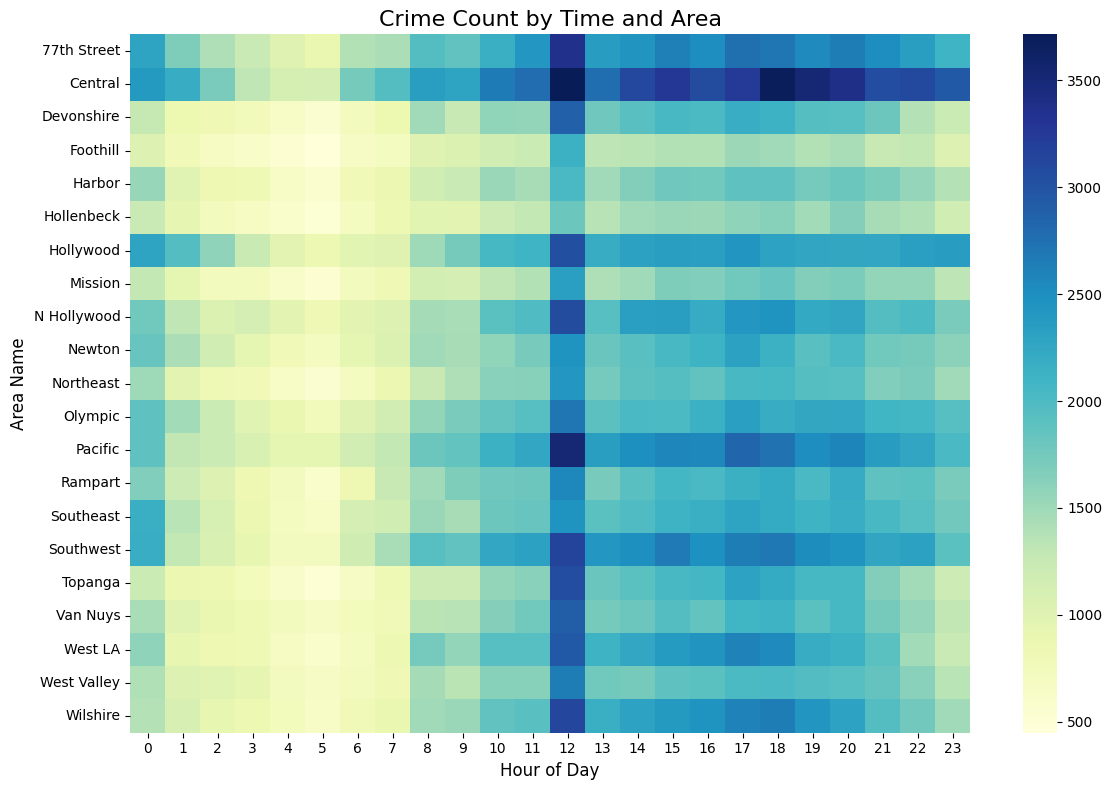

In [22]:
# Ensure 4-digit format for time_occ
df['time_occ'] = df['time_occ'].astype(str).str.zfill(4)
# Format time_occ as HH:MM
df['time_occ'] = df['time_occ'].str.replace(r'(\d{2})(\d{2})', r'\1:\2', regex=True)
# Extract hour as an integer
df['hour'] = df['time_occ'].str[:2].astype(int)

# Group by area_name and hour, and count crimes
if 'area_name' in df.columns:
    time_area_counts = df.groupby(['area_name', 'hour']).size().reset_index(name='Crime Count')
else:
    print("area_name column not found in dataset.")

# Pivot data to create a heatmap-compatible DataFrame
heatmap_data = time_area_counts.pivot(index='area_name', columns='hour', values='Crime Count').fillna(0)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Crime Count by Time and Area", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Area Name", fontsize=12)
plt.tight_layout()
plt.show()


*Crime Count by Area name and time*
----------------------------------

+ Peak Crime Hours:
Crimes tend to peak around 12:00 PM (noon) across multiple areas, as indicated by the darkest cells in the heatmap.
A noticeable increase in crime activity is also observed during the early evening hours, particularly between 5:00 PM and 9:00 PM in some areas.

+ High-Crime Areas:
Certain areas like Central, Rampart, and Hollywood show consistently higher crime counts compared to others, especially during the peak hours. These areas may require enhanced monitoring and resource allocation.

+ Low-Crime Times:
Early morning hours, such as between 2:00 AM and 6:00 AM, generally exhibit the lowest crime activity across all areas. This is likely due to reduced human activity during these hours.
Area-Specific Insights:

*Areas like Northeast and Van Nuys show a relatively uniform distribution of crime throughout the day, with no sharp peaks compared to areas like Central or Hollywood*

Overall, this analysis reveals significant variations in crime patterns across time and locations, which can inform strategic decision-making for crime reduction and community safety initiatives.

In [23]:
# Total crimes per area
crime_by_area = df.groupby('area_name').size().reset_index(name='crime_count')

# Add latitude and longitude for mapping if available
location_data = df[['area_name', 'lat', 'lon']].drop_duplicates()
crime_by_area = crime_by_area.merge(location_data, on='area_name', how='left')

print(crime_by_area.head())


     area_name  crime_count      lat       lon
0  77th Street        50672  33.9785 -118.3068
1  77th Street        50672  33.9837 -118.3216
2  77th Street        50672  33.9610 -118.2739
3  77th Street        50672  33.9679 -118.2695
4  77th Street        50672  33.9739 -118.2630


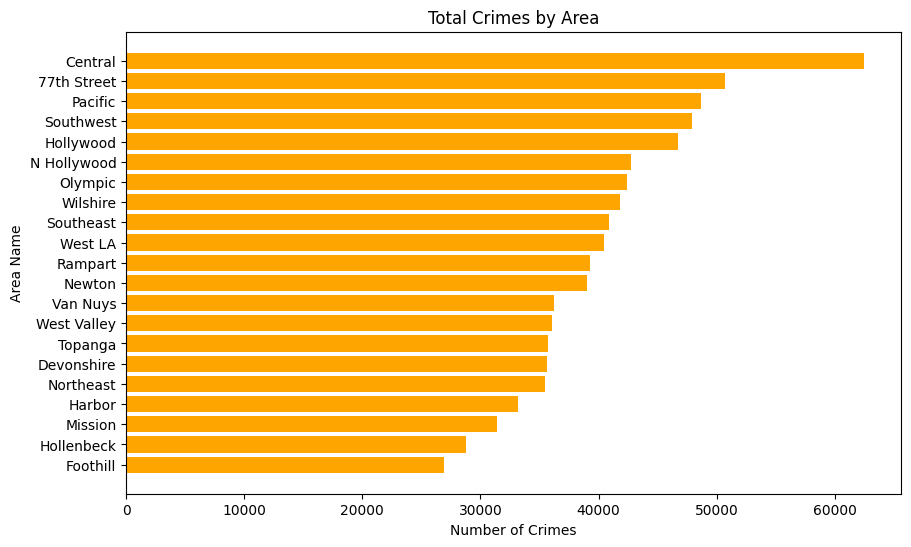

In [24]:
import matplotlib.pyplot as plt

# Sort by crime count for better visualization
sorted_crime_by_area = crime_by_area.sort_values('crime_count', ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.barh(sorted_crime_by_area['area_name'], sorted_crime_by_area['crime_count'], color='orange')
plt.xlabel('Number of Crimes')
plt.ylabel('Area Name')
plt.title('Total Crimes by Area')
plt.gca().invert_yaxis()  # To display the highest crime area at the top
plt.show()


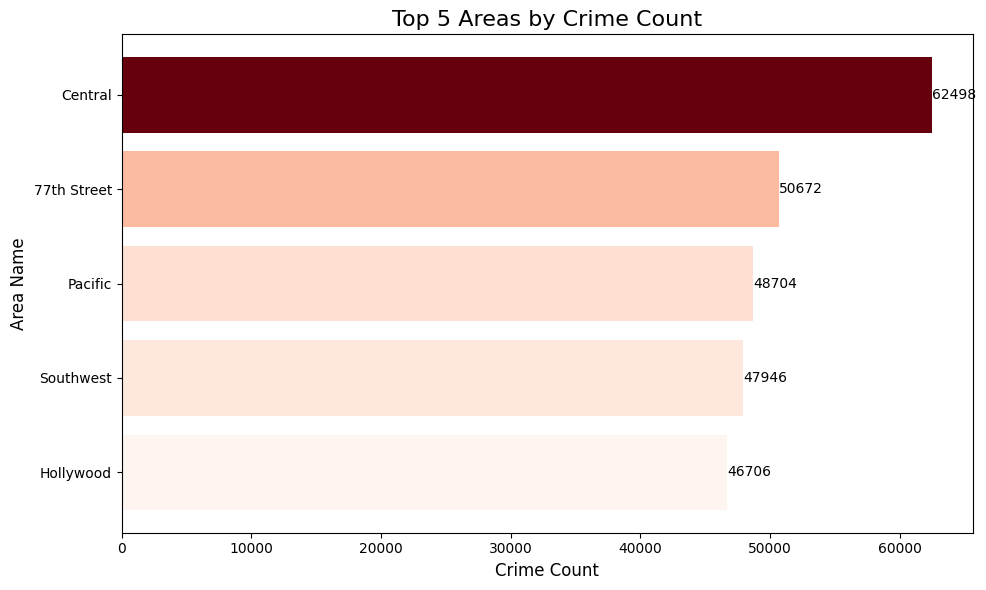

In [25]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Assuming `df` contains the dataset with an 'area_name' column

# Step 1: Group by 'area_name' and count crimes
crime_by_area = (
    df.groupby('area_name')
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Step 2: Select the top 5 areas
top_5_areas = crime_by_area.head(5)

# Step 3: Create a gradient function for colors
def create_gradient_color(values, cmap_name='Reds'):
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(values.min(), values.max())
    return [cmap(norm(value)) for value in values]

# Step 4: Generate gradient colors based on crime counts
colors = create_gradient_color(top_5_areas['crime_count'])

# Step 5: Plot horizontal bar graph with gradient colors
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_5_areas['area_name'], top_5_areas['crime_count'], color=colors)
ax.set_xlabel('Crime Count', fontsize=12)
ax.set_ylabel('Area Name', fontsize=12)
ax.set_title('Top 5 Areas by Crime Count', fontsize=16)
ax.invert_yaxis()  # To display the highest crime area at the top

# Add labels to bars for better visualization
for bar, value in zip(bars, top_5_areas['crime_count']):
    ax.text(
        bar.get_width() + 5,  # Position to the right of the bar
        bar.get_y() + bar.get_height() / 2,  # Vertically centered
        f'{int(value)}',  # Display crime count
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [26]:
import folium
from folium.plugins import HeatMap

# Filter data for heatmap
heatmap_data = crime_by_area[['lat', 'lon', 'crime_count']].dropna()

# Create base map
la_map = folium.Map(location=[34.0522, -118.2437], zoom_start=10)  # Centered on LA

# Add heatmap
HeatMap(data=heatmap_data[['lat', 'lon', 'crime_count']].values.tolist(),
        radius=15, blur=10, max_zoom=1).add_to(la_map)

# Display map
la_map.save('la_crime_heatmap.html')
print("Heatmap saved as 'la_crime_heatmap.html'. Open this file in your browser.")


KeyError: "['lat', 'lon'] not in index"

In [27]:
#three areas with least amount of crimes in LA(safest)


import folium
from folium.plugins import HeatMap

# Example: Assuming the DataFrame `df` contains the necessary data
# Replace with your actual dataset
# The DataFrame should have 'area_name', 'lat', 'lon', and optionally 'crime_count'

# Filter the data for the specified areas
selected_areas = ['Foothill', 'Hollenbeck', 'Mission']
filtered_data = df[df['area_name'].isin(selected_areas)].dropna(subset=['lat', 'lon'])

# Aggregate data for the heatmap if needed
# For simplicity, assuming one location per area (latitude/longitude pair)
heatmap_data = filtered_data[['lat', 'lon']]

# Create the base map centered on LA
la_map = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

# Add heatmap for the selected areas
HeatMap(data=heatmap_data.values.tolist(), radius=15, blur=10, max_zoom=1).add_to(la_map)

# Save and display the map
la_map.save('foothill_hollenbeck_mission_heatmap.html')
print("Heatmap saved as 'foothill_hollenbeck_mission_heatmap.html'. Open this file in your browser.")


Heatmap saved as 'foothill_hollenbeck_mission_heatmap.html'. Open this file in your browser.


In [28]:
pip install geopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 8.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [29]:

# Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Group by latitude and longitude to find crime counts per location
top_locations = central_data.groupby(['lat', 'lon']).size().reset_index(name='crime_count')

# Sort by crime count to get the top 5 locations
top_5_locations = top_locations.nlargest(5, 'crime_count')

# Display the top 5 locations
print("Top 5 locations with the highest crime counts in the Central area:")
print(top_5_locations)


Top 5 locations with the highest crime counts in the Central area:
          lat       lon  crime_count
1259  34.0561 -118.2375         2325
896   34.0483 -118.2631         1729
877   34.0480 -118.2577         1095
526   34.0421 -118.2469          750
748   34.0460 -118.2510          702


In [30]:
import folium

# Filter data for 77th Street, Pacific, and Central areas
selected_areas = ['77th Street', 'Pacific', 'Central']
filtered_data = df[df['area_name'].isin(selected_areas)]

# Group by area, latitude, and longitude to calculate crime counts
top_locations = filtered_data.groupby(['area_name', 'lat', 'lon']).size().reset_index(name='crime_count')

# Separate data for each area and get top 5 locations for each
top_77th = top_locations[top_locations['area_name'] == '77th Street'].nlargest(5, 'crime_count')
top_pacific = top_locations[top_locations['area_name'] == 'Pacific'].nlargest(5, 'crime_count')
top_central = top_locations[top_locations['area_name'] == 'Central'].nlargest(5, 'crime_count')

# Create a map centered on Los Angeles
crime_map = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 5 locations in 77th Street
for _, row in top_77th.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"77th Street - Crimes: {row['crime_count']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(crime_map)

# Add markers for the top 5 locations in Pacific
for _, row in top_pacific.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Pacific - Crimes: {row['crime_count']}",
        icon=folium.Icon(color='green', icon='info-sign')
    ).add_to(crime_map)

# Add markers for the top 5 locations in Central
for _, row in top_central.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Central - Crimes: {row['crime_count']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(crime_map)

# Save the map to an HTML file
crime_map.save('top_5_crime_locations_combined.html')
print("Map saved as 'top_5_crime_locations_combined.html'.")


Map saved as 'top_5_crime_locations_combined.html'.


In [31]:
import folium

# Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Group by latitude and longitude to calculate crime counts for the Central area
central_crime_by_location = central_data.groupby(['lat', 'lon']).size().reset_index(name='crime_count')

# Get the top 10 locations with the highest crime counts in the Central area
top_10_central_locations = central_crime_by_location.nlargest(10, 'crime_count')

# Create a map centered on Los Angeles
central_top_crime_map = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 10 locations in the Central area
for _, row in top_10_central_locations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Crimes: {row['crime_count']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(central_top_crime_map)

# Save the map to an HTML file
central_top_crime_map.save('top_10_central_crime_locations.html')
print("Map saved as 'top_10_central_crime_locations.html'. Open this file in your browser.")


Map saved as 'top_10_central_crime_locations.html'. Open this file in your browser.


In [32]:
# Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Group by latitude and longitude to calculate crime counts for the Central area
central_crime_by_location = central_data.groupby(['lat', 'lon']).size().reset_index(name='crime_count')

# Get the top 10 locations with the highest crime counts in the Central area
top_10_central_locations = central_crime_by_location.nlargest(10, 'crime_count')

# Display the latitude and longitude for the top 10 locations
top_10_central_locations[['lat', 'lon', 'crime_count']]


,lat,lon,crime_count
1259,34.0561,-118.2375,2325
896,34.0483,-118.2631,1729
877,34.0480,-118.2577,1095
526,34.0421,-118.2469,750
748,34.0460,-118.2510,702
1033,34.0508,-118.2586,669
793,34.0467,-118.2520,644
789,34.0466,-118.2520,640
936,34.0488,-118.2518,606
764,34.0462,-118.2585,518


In [33]:
from geopy.distance import geodesic

# Define the target location
griffith_park = (34.136, -118.294)

# Calculate distances from the target location for the top 10 Central crime locations
top_10_central_locations['distance_to_target'] = top_10_central_locations.apply(
    lambda row: geodesic((row['lat'], row['lon']),griffith_park).miles, axis=1
)

# Find the datapoint closest to the target location
closest_location = top_10_central_locations.nsmallest(1, 'distance_to_target')

# Display the closest datapoint
closest_location[['lat', 'lon', 'crime_count', 'distance_to_target']]


,lat,lon,crime_count,distance_to_target
1033,34.0508,-118.2586,669,6.213356


In [34]:
import folium

# Assuming `top_10_central_locations` DataFrame is recreated with 'lat', 'lon', and 'crime_count'

# Define the target location (Griffith Park)
griffith_park = (34.136, -118.294)

# Create a map centered on Los Angeles
map_with_griffith = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 10 Central area crime locations
for _, row in top_10_central_locations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Crime Count: {row['crime_count']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_with_griffith)

# Add a marker for Griffith Park as a tourist spot
folium.Marker(
    location=griffith_park,
    popup="Griffith Park (Tourist Location)",
    icon=folium.Icon(color='blue', icon='star')
).add_to(map_with_griffith)

# Save the map to an HTML file
map_with_griffith.save('central_area_with_griffith_park.html')
print("Map saved as 'central_area_with_griffith_park.html'. Open this file in your browser.")


Map saved as 'central_area_with_griffith_park.html'. Open this file in your browser.


In [35]:
from geopy.distance import geodesic
import pandas as pd

# Crime locations data
crime_locations = pd.DataFrame({
    'lat': [34.0561, 34.0483, 34.0480, 34.0421, 34.0460, 34.0508, 34.0467, 34.0466, 34.0488, 34.0462],
    'lon': [-118.2375, -118.2631, -118.2577, -118.2469, -118.2510, -118.2586, -118.2520, -118.2520, -118.2518, -118.2585],
    'crime_count': [2325, 1729, 1095, 750, 702, 669, 644, 640, 606, 518]
})

# Tourist attractions in Central area
tourist_attractions = pd.DataFrame({
    'name': ['Griffith Park', 'The Broad', 'Walt Disney Concert Hall', 'Union Station', 'Grand Central Market','The Last Bookstore','Angels Flight Railway', 'Bradbury Building', 'OUE Skyspace LA',
        'Little Tokyo', 'The Jewelry District'],
    'lat': [34.136, 34.0544, 34.0553, 34.0560, 34.0509,34.048,34.0526, 34.0500, 34.0522, 34.0491, 34.0469],
    'lon': [-118.294, -118.2509, -118.2498, -118.2361, -118.2488,-118.249,-118.2491, -118.2478, -118.2565, -118.2416, -118.2517]
})

# Function to calculate the closest tourist attraction for a given crime location
def find_closest_tourist_attraction(crime_lat, crime_lon):
    distances = tourist_attractions.apply(
        lambda row: geodesic((crime_lat, crime_lon), (row['lat'], row['lon'])).miles, axis=1
    )
    closest_idx = distances.idxmin()
    return tourist_attractions.loc[closest_idx, 'name'], distances.min()

# Apply the function to each crime location
crime_locations[['closest_tourist', 'distance']] = crime_locations.apply(
    lambda row: find_closest_tourist_attraction(row['lat'], row['lon']), axis=1, result_type='expand'
)

# Display the results
print("Crime Locations with Closest Tourist Attractions:")
print(crime_locations[['lat', 'lon', 'crime_count', 'closest_tourist', 'distance']])


Crime Locations with Closest Tourist Attractions:
       lat       lon  crime_count       closest_tourist  distance
0  34.0561 -118.2375         2325         Union Station  0.080610
1  34.0483 -118.2631         1729       OUE Skyspace LA  0.464363
2  34.0480 -118.2577         1095       OUE Skyspace LA  0.297557
3  34.0421 -118.2469          750    The Last Bookstore  0.424129
4  34.0460 -118.2510          702  The Jewelry District  0.073898
5  34.0508 -118.2586          669       OUE Skyspace LA  0.154357
6  34.0467 -118.2520          644  The Jewelry District  0.022052
7  34.0466 -118.2520          640  The Jewelry District  0.026904
8  34.0488 -118.2518          606  The Jewelry District  0.131082
9  34.0462 -118.2585          518  The Jewelry District  0.393115


In [36]:
import folium
from geopy.distance import geodesic
import pandas as pd

# Crime locations data
crime_locations = pd.DataFrame({
    'lat': [34.0561, 34.0483, 34.0480, 34.0421, 34.0460, 34.0508, 34.0467, 34.0466, 34.0488, 34.0462],
    'lon': [-118.2375, -118.2631, -118.2577, -118.2469, -118.2510, -118.2586, -118.2520, -118.2520, -118.2518, -118.2585],
    'crime_count': [2325, 1729, 1095, 750, 702, 669, 644, 640, 606, 518]
})

# Tourist attractions in Central area
tourist_attractions = pd.DataFrame({
    'name': ['Griffith Park', 'The Broad', 'Walt Disney Concert Hall', 'Union Station', 'Grand Central Market','The Last Bookstore','Angels Flight Railway', 'Bradbury Building', 'OUE Skyspace LA',
        'Little Tokyo', 'The Jewelry District'],
    'lat': [34.136, 34.0544, 34.0553, 34.0560, 34.0509,34.048,34.0526, 34.0500, 34.0522, 34.0491, 34.0469],
    'lon': [-118.294, -118.2509, -118.2498, -118.2361, -118.2488,-118.249,-118.2491, -118.2478, -118.2565, -118.2416, -118.2517]
})

# Function to calculate the closest tourist attraction for a given crime location
def find_closest_tourist_attraction(crime_lat, crime_lon):
    distances = tourist_attractions.apply(
        lambda row: geodesic((crime_lat, crime_lon), (row['lat'], row['lon'])).miles, axis=1
    )
    closest_idx = distances.idxmin()
    return tourist_attractions.loc[closest_idx, 'name'], distances.min()

# Apply the function to each crime location
crime_locations[['closest_tourist', 'distance']] = crime_locations.apply(
    lambda row: find_closest_tourist_attraction(row['lat'], row['lon']), axis=1, result_type='expand'
)

# Create a map centered on Los Angeles
map_with_tourist_places = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 10 crime locations
for _, row in crime_locations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Crime Count: {row['crime_count']}<br>Closest Tourist Place: {row['closest_tourist']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_with_tourist_places)

# Add markers for tourist attractions
for _, row in tourist_attractions.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Tourist Place: {row['name']}",
        icon=folium.Icon(color='blue', icon='star')
    ).add_to(map_with_tourist_places)

# Save the map to an HTML file
map_with_tourist_places.save('central_crime_with_tourist_places.html')
print("Map saved as 'central_crime_with_tourist_places.html'. Open this file in your browser.")


Map saved as 'central_crime_with_tourist_places.html'. Open this file in your browser.


In [38]:
# Step 1: Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Step 2: Group by latitude, longitude, and location to calculate crime counts
grouped_crime_by_location = (
    central_data.groupby(['lat', 'lon', 'location'])
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Step 3: Get the top 10 crime locations
top_10_crime_locations = grouped_crime_by_location.head(10)

# Step 4: Display the results
top_10_crime_locations[['location', 'lat', 'lon', 'crime_count']]

,location,lat,lon,crime_count
4304,800 N ALAMEDA ST,34.0561,-118.2375,2325
3182,700 S FIGUEROA ST,34.0483,-118.2631,1571
3112,700 W 7TH ST,34.0480,-118.2577,807
3664,600 S FIGUEROA ST,34.0508,-118.2586,666
2802,600 S BROADWAY,34.0466,-118.2520,535
3302,500 S HILL ST,34.0488,-118.2518,490
2061,500 S SAN PEDRO ST,34.0437,-118.2455,417
2619,600 S SPRING ST,34.0460,-118.2510,379
2376,800 S OLIVE ST,34.0452,-118.2569,371
1725,600 S SAN PEDRO ST,34.0421,-118.2469,352


In [39]:
import folium

# Assuming `top_10_crime_locations` and `tourist_attractions` DataFrames are available

# Example data for tourist attractions
tourist_attractions = pd.DataFrame({
    'name': ['Griffith Park', 'The Broad', 'Walt Disney Concert Hall', 'Union Station', 'Grand Central Market','The Last Bookstore','Angels Flight Railway', 'Bradbury Building', 'OUE Skyspace LA',
        'Little Tokyo', 'The Jewelry District'],
    'lat': [34.136, 34.0544, 34.0553, 34.0560, 34.0509,34.048,34.0526, 34.0500, 34.0522, 34.0491, 34.0469],
    'lon': [-118.294, -118.2509, -118.2498, -118.2361, -118.2488,-118.249,-118.2491, -118.2478, -118.2565, -118.2416, -118.2517]
})

# Create a map centered on Los Angeles
map_with_locations = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 10 crime locations
for _, row in top_10_crime_locations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Crime Location: {row['location']}<br>Crime Count: {row['crime_count']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_with_locations)

# Add markers for tourist attractions
for _, row in tourist_attractions.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Tourist Place: {row['name']}",
        icon=folium.Icon(color='blue', icon='star')
    ).add_to(map_with_locations)

# Save the map to an HTML file
map_with_locations.save('central_area_top_10_crime_with_tourist_locations.html')
print("Map saved as 'central_area_top_10_crime_with_tourist_locations.html'. Open this file in your browser.")


Map saved as 'central_area_top_10_crime_with_tourist_locations.html'. Open this file in your browser.


In [40]:
# Step 1: Group by premise description and calculate the total crime count for the Central area
premise_crime_counts = (
    central_data.groupby('premis_desc')
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Step 2: Filter for the top 10 premise descriptions
top_10_premises = premise_crime_counts.head(10)

# Step 3: Filter the original Central area data to include only the top 10 premises
top_10_premises_data = central_data[central_data['premis_desc'].isin(top_10_premises['premis_desc'])]

# Step 4: Group by latitude, longitude, and premise description to calculate crime counts
grouped_top_premises = (
    top_10_premises_data.groupby(['lat', 'lon', 'premis_desc'])
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Display the grouped data for the top 10 premise descriptions
grouped_top_premises


,lat,lon,premis_desc,crime_count
4528,34.0561,-118.2375,LA UNION STATION (NOT LINE SPECIFIC),1483
3299,34.0483,-118.2631,DEPARTMENT STORE,736
3211,34.0480,-118.2577,DEPARTMENT STORE,508
1702,34.0421,-118.2469,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",362
2643,34.0460,-118.2510,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",281
...,...,...,...,...
2691,34.0461,-118.2475,PARKING UNDERGROUND/BUILDING,1
2703,34.0461,-118.2395,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",1
2704,34.0461,-118.2395,OTHER BUSINESS,1
2709,34.0462,-118.2687,PARKING LOT,1


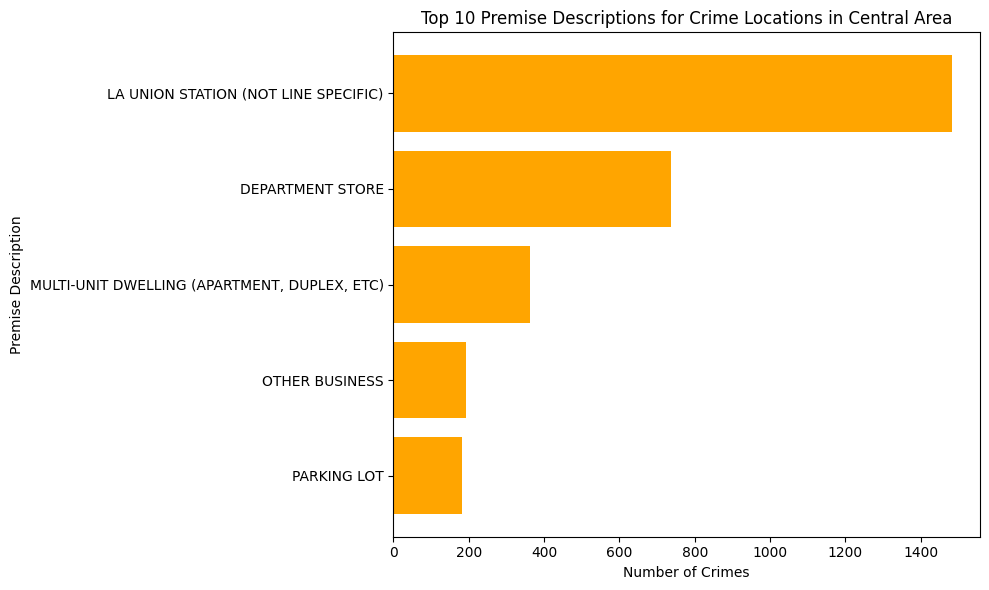

In [41]:
import matplotlib.pyplot as plt

# Assuming `grouped_premises_top_10` DataFrame is created with 'premis_desc' and 'crime_count'

# Step 1: Select the top 10 records from grouped data
top_10_records = grouped_top_premises.head(10)

# Step 2: Plot the graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_records['premis_desc'], top_10_records['crime_count'], color='orange')
plt.xlabel('Number of Crimes')
plt.ylabel('Premise Description')
plt.title('Top 10 Premise Descriptions for Crime Locations in Central Area')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.tight_layout()
plt.show()


In [42]:
# Assuming the original dataset `df` includes columns 'area_name', 'lat', 'lon', and 'location'

# Step 1: Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Step 2: Calculate crime counts for each location (latitude and longitude)
crime_by_location = (
    central_data.groupby(['lat', 'lon'])
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Step 3: Get the top 10 crime locations
top_10_central_locations = crime_by_location.head(10)

# Step 4: Merge with the original data to get the 'location' column for the top 10 locations
top_10_with_location = central_data.merge(
    top_10_central_locations[['lat', 'lon']],
    on=['lat', 'lon'],
    how='inner'
)

# Step 5: Group by 'location' and calculate the total crime counts
grouped_by_location = (
    top_10_with_location.groupby('location')
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Display the grouped data
grouped_by_location.head(10)  # Top 10 grouped by 'location'


,location,crime_count
47,800 N ALAMEDA ST,2325
36,700 S FIGUEROA ST,1571
40,700 W 7TH ST,807
28,600 S FIGUEROA ST,666
30,600 S SPRING ST,578
27,600 S BROADWAY,550
18,500 S HILL ST,490
29,600 S SAN PEDRO ST,352
20,500 S SPRING ST,306
4,200 W 6TH ST,279


In [43]:
# Step 1: Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Step 2: Group by latitude, longitude, and location to calculate crime counts
grouped_crime_by_location = (
    central_data.groupby(['lat', 'lon', 'location'])
    .size()
    .reset_index(name='crime_count')
    .sort_values(by='crime_count', ascending=False)
)

# Step 3: Get the top 10 crime locations
top_10_crime_locations = grouped_crime_by_location.head(10)

# Step 4: Display the results
top_10_crime_locations[['location', 'lat', 'lon', 'crime_count']]


,location,lat,lon,crime_count
4304,800 N ALAMEDA ST,34.0561,-118.2375,2325
3182,700 S FIGUEROA ST,34.0483,-118.2631,1571
3112,700 W 7TH ST,34.0480,-118.2577,807
3664,600 S FIGUEROA ST,34.0508,-118.2586,666
2802,600 S BROADWAY,34.0466,-118.2520,535
3302,500 S HILL ST,34.0488,-118.2518,490
2061,500 S SAN PEDRO ST,34.0437,-118.2455,417
2619,600 S SPRING ST,34.0460,-118.2510,379
2376,800 S OLIVE ST,34.0452,-118.2569,371
1725,600 S SAN PEDRO ST,34.0421,-118.2469,352


In [44]:
import folium

# Assuming `top_10_crime_locations` and `tourist_attractions` DataFrames are available

# Example data for tourist attractions
tourist_attractions = pd.DataFrame({
     'name': ['Griffith Park', 'The Broad', 'Walt Disney Concert Hall', 'Union Station', 'Grand Central Market','The Last Bookstore','Angels Flight Railway', 'Bradbury Building', 'OUE Skyspace LA',
        'Little Tokyo', 'The Jewelry District'],
    'lat': [34.136, 34.0544, 34.0553, 34.0560, 34.0509,34.048,34.0526, 34.0500, 34.0522, 34.0491, 34.0469],
    'lon': [-118.294, -118.2509, -118.2498, -118.2361, -118.2488,-118.249,-118.2491, -118.2478, -118.2565, -118.2416, -118.2517]
})

# Create a map centered on Los Angeles
map_with_locations = folium.Map(location=[34.0522, -118.2437], zoom_start=12)

# Add markers for the top 10 crime locations
for _, row in top_10_crime_locations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Crime Location: {row['location']}<br>Crime Count: {row['crime_count']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map_with_locations)

# Add markers for tourist attractions
for _, row in tourist_attractions.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Tourist Place: {row['name']}",
        icon=folium.Icon(color='blue', icon='star')
    ).add_to(map_with_locations)

# Save the map to an HTML file
map_with_locations.save('central_area_top_10_crime_with_tourist_locations.html')
print("Map saved as 'central_area_top_10_crime_with_tourist_locations.html'. Open this file in your browser.")


Map saved as 'central_area_top_10_crime_with_tourist_locations.html'. Open this file in your browser.


In [45]:
# Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Ensure 4-digit format for time_occ
central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)

# Extract hour from time_occ
central_data['hour'] = central_data['time_occ'].str[:2].astype(int)

# Group by hour and count the crimes
crime_by_hour = central_data.groupby('hour').size().reset_index(name='Crime Count')

# Find the hour with the most crimes
most_crime_hour = crime_by_hour.loc[crime_by_hour['Crime Count'].idxmax()]

most_crime_hour


/tmp/ipykernel_221/2964302008.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)
/tmp/ipykernel_221/2964302008.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['hour'] = central_data['time_occ'].str[:2].astype(int)


hour             12
Crime Count    3715
Name: 12, dtype: int64

In [46]:
# Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Ensure 4-digit format for time_occ
central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)

# Extract hour from time_occ
central_data['hour'] = central_data['time_occ'].str[:2].astype(int)

# Group by location and hour, and count crimes
crime_by_hour_location = (
    central_data.groupby(['location', 'hour'])
    .size()
    .reset_index(name='Crime Count')
)

# Find the location and hour with the most crimes
most_crime_hour_location = crime_by_hour_location.loc[
    crime_by_hour_location['Crime Count'].idxmax()
]

most_crime_hour_location


/tmp/ipykernel_221/1784086015.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)
/tmp/ipykernel_221/1784086015.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['hour'] = central_data['time_occ'].str[:2].astype(int)


location       800 N  ALAMEDA                      ST
hour                                                6
Crime Count                                       301
Name: 10077, dtype: object

In [47]:
# Assuming `df` contains the dataset with 'area_name', 'time_occ', 'lat', 'lon', and 'location'

# Step 1: Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Step 2: Ensure 4-digit format for time_occ and extract the hour
central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)
central_data['hour'] = central_data['time_occ'].str[:2].astype(int)

# Step 3: Group by latitude and longitude to calculate crime counts
crime_by_location = (
    central_data.groupby(['lat', 'lon', 'location'])
    .size()
    .reset_index(name='Crime Count')
    .sort_values(by='Crime Count', ascending=False)
)

# Step 4: Get the top 10 locations with the highest crime counts
top_10_locations = crime_by_location.head(10)

# Step 5: Filter the central_data for the top 10 locations
filtered_top_10_data = central_data.merge(
    top_10_locations[['lat', 'lon', 'location']],
    on=['lat', 'lon', 'location'],
    how='inner'
)

# Step 6: Group by location and hour for the top 10 locations
crime_by_hour_top_10 = (
    filtered_top_10_data.groupby(['location', 'hour'])
    .size()
    .reset_index(name='Crime Count')
)

# Step 7: Find the hour with the most crimes for each location in ascending order
most_crime_hour_top_10 = (
    crime_by_hour_top_10.loc[
        crime_by_hour_top_10.groupby('location')['Crime Count'].idxmax()
    ]
    .sort_values(by='Crime Count', ascending=False)
)

most_crime_hour_top_10


/tmp/ipykernel_221/4075050614.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['time_occ'] = central_data['time_occ'].astype(str).str.zfill(4)
/tmp/ipykernel_221/4075050614.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_data['hour'] = central_data['time_occ'].str[:2].astype(int)


,location,hour,Crime Count
196,800 N ALAMEDA ST,6,294
160,700 S FIGUEROA ST,18,177
180,700 W 7TH ST,14,86
15,500 S HILL ST,15,67
56,600 S BROADWAY,9,59
85,600 S FIGUEROA ST,14,59
120,600 S SPRING ST,1,46
236,800 S OLIVE ST,22,36
107,600 S SAN PEDRO ST,12,32
24,500 S SAN PEDRO ST,0,31


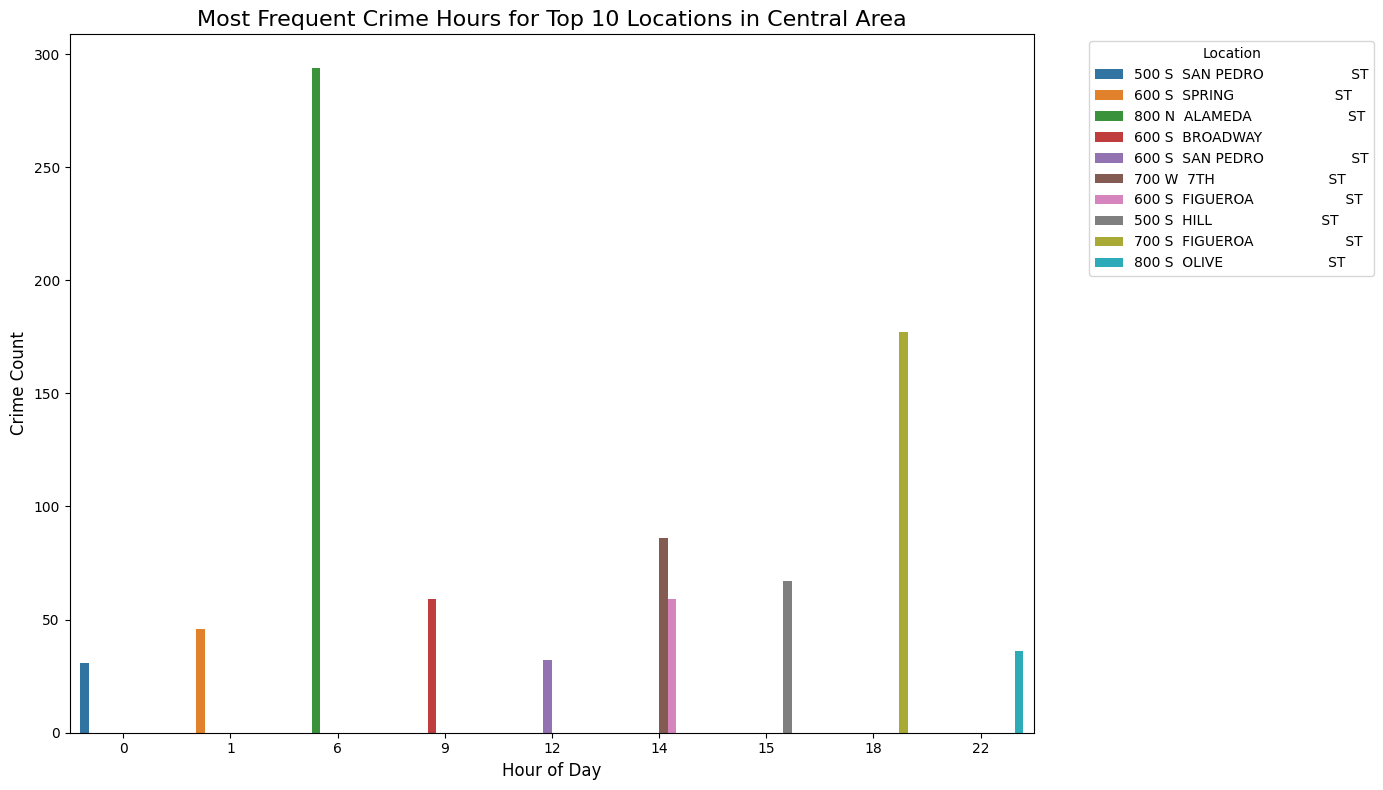

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming `most_crime_hour_top_10` DataFrame is created with 'location', 'hour', and 'Crime Count'

# Create a bar plot for the most frequent crime hours in the top 10 locations
plt.figure(figsize=(14, 8))
sns.barplot(
    x='hour', 
    y='Crime Count', 
    hue='location', 
    data=most_crime_hour_top_10, 
    dodge=True
)

plt.title("Most Frequent Crime Hours for Top 10 Locations in Central Area", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Crime Count", fontsize=12)
plt.legend(title="Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [49]:
# Assuming `df` contains the dataset with 'area_name', 'lat', 'lon', 'location', and 'crm_cd_desc' (crime type)

# Step 1: Filter data for the Central area
central_data = df[df['area_name'] == 'Central']

# Step 2: Group by latitude, longitude, and location to calculate crime counts
crime_by_location = (
    central_data.groupby(['lat', 'lon', 'location'])
    .size()
    .reset_index(name='Crime Count')
    .sort_values(by='Crime Count', ascending=False)
)

# Step 3: Get the top 10 crime locations
top_10_locations = crime_by_location.head(10)

# Step 4: Filter the central_data for the top 10 locations
filtered_top_10_data = central_data.merge(
    top_10_locations[['lat', 'lon', 'location']],
    on=['lat', 'lon', 'location'],
    how='inner'
)

# Step 5: Group by location and crime type (crm_cd_desc) for the top 10 locations
crime_types_top_10 = (
    filtered_top_10_data.groupby(['location', 'crm_cd_desc'])
    .size()
    .reset_index(name='Crime Count')
    .sort_values(by='Crime Count', ascending=False)
)

# Display the results
crime_types_top_10.head(20)  # Show top 20 for readability


,location,crm_cd_desc,Crime Count
226,700 S FIGUEROA ST,SHOPLIFTING - PETTY THEFT ($950 & UNDER),1059
323,800 N ALAMEDA ST,TRESPASSING,964
262,700 W 7TH ST,SHOPLIFTING - PETTY THEFT ($950 & UNDER),503
280,800 N ALAMEDA ST,BATTERY - SIMPLE ASSAULT,390
93,600 S BROADWAY,SHOPLIFTING - PETTY THEFT ($950 & UNDER),381
31,500 S HILL ST,TRESPASSING,341
128,600 S FIGUEROA ST,TRESPASSING,332
319,800 N ALAMEDA ST,THEFT PLAIN - PETTY ($950 & UNDER),207
333,800 S OLIVE ST,BURGLARY FROM VEHICLE,177
232,700 S FIGUEROA ST,THEFT PLAIN - PETTY ($950 & UNDER),127


In [50]:
central_data = df[df['area_name'] == 'Central']


crime_by_location = (
    central_data.groupby(['lat', 'lon', 'location'])
    .size()
    .reset_index(name='Crime Count')
    .sort_values(by='Crime Count', ascending=False)
)

top_10_locations = crime_by_location.head(10)


filtered_top_10_data = central_data.merge(
    top_10_locations[['lat', 'lon', 'location']],
    on=['lat', 'lon', 'location'],
    how='inner'
)


crime_types_grouped = (
    filtered_top_10_data.groupby(['location', 'crm_cd_desc'])
    .size()
    .reset_index(name='Crime Count')
    .sort_values(by=['location', 'Crime Count'], ascending=False)
)

highest_crime_per_location = (
    crime_types_grouped.loc[
        crime_types_grouped.groupby('location')['Crime Count'].idxmax()
    ]
)

print(highest_crime_per_location)



                                   location  \
31   500 S  HILL                         ST   
37   500 S  SAN PEDRO                    ST   
93                          600 S  BROADWAY   
128  600 S  FIGUEROA                     ST   
134  600 S  SAN PEDRO                    ST   
177  600 S  SPRING                       ST   
226  700 S  FIGUEROA                     ST   
262  700 W  7TH                          ST   
323  800 N  ALAMEDA                      ST   
333  800 S  OLIVE                        ST   

                                  crm_cd_desc  Crime Count  
31                                TRESPASSING          341  
37                   BATTERY - SIMPLE ASSAULT           90  
93   SHOPLIFTING - PETTY THEFT ($950 & UNDER)          381  
128                               TRESPASSING          332  
134                  BATTERY - SIMPLE ASSAULT           75  
177                     BURGLARY FROM VEHICLE           73  
226  SHOPLIFTING - PETTY THEFT ($950 & UNDER)         1

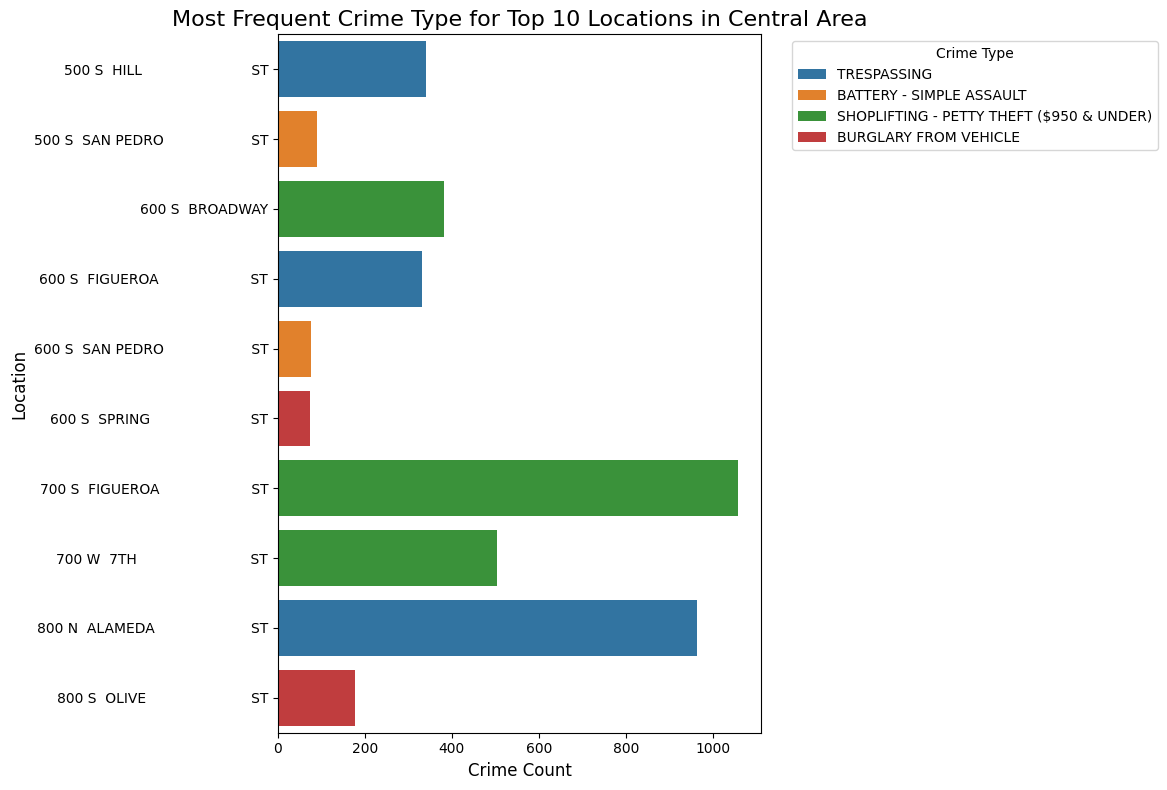

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `highest_crime_per_location` DataFrame is created with 'location', 'crm_cd_desc', and 'Crime Count'

# Plot the data
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Crime Count', 
    y='location', 
    hue='crm_cd_desc', 
    data=highest_crime_per_location, 
    dodge=False
)

plt.title("Most Frequent Crime Type for Top 10 Locations in Central Area", fontsize=16)
plt.xlabel("Crime Count", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/tmp/ipykernel_221/3863070285.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


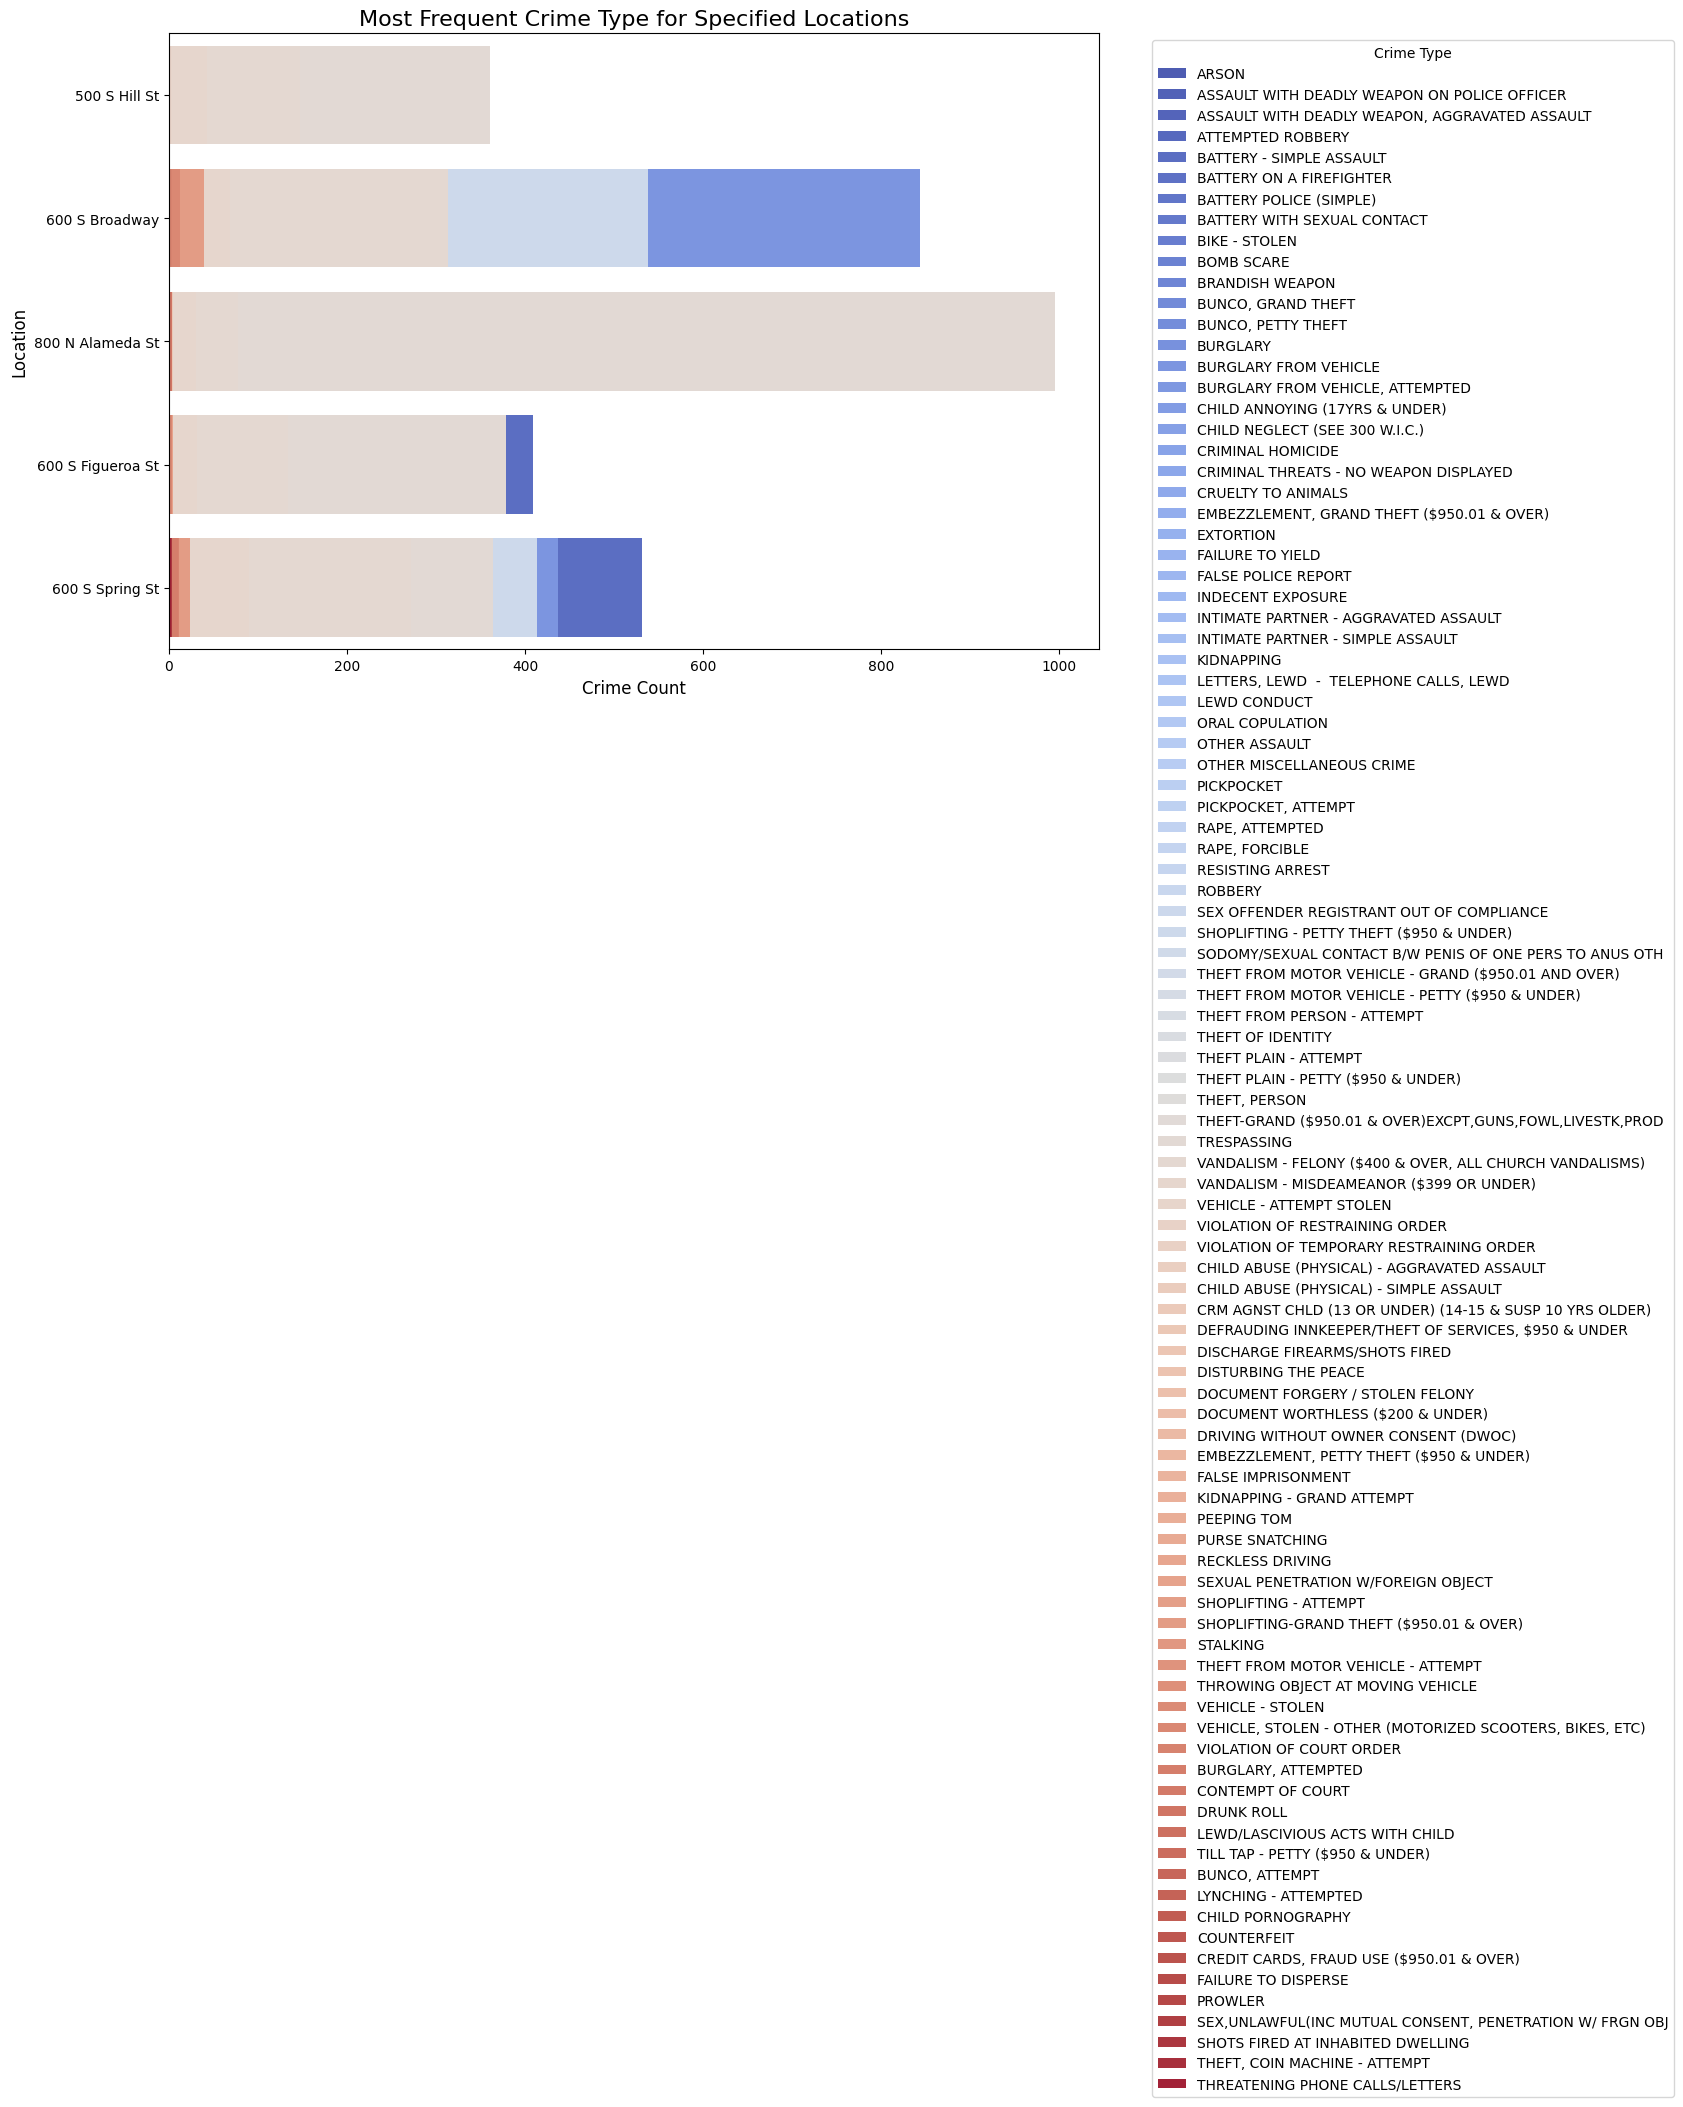

In [58]:
# Assuming `df` contains the actual dataset with columns 'lat', 'lon', 'crm_cd_desc', and 'Crime Count'

# Specified locations with their coordinates
location_coords = {
    "500 S Hill St": (34.0505, -118.2525),
    "600 S Broadway": (34.0472, -118.2568),
    "800 N Alameda St": (34.0564, -118.2362),
    "600 S Figueroa St": (34.0502, -118.2598),
    "600 S Spring St": (34.0469, -118.2512)
}

# Initialize a DataFrame to store results
results = []

for loc, coords in location_coords.items():
    # Filter crimes near the given coordinates (small radius, e.g., 0.002 degrees)
    nearby_crimes = df[
        (df['lat'].between(coords[0] - 0.002, coords[0] + 0.002)) &
        (df['lon'].between(coords[1] - 0.002, coords[1] + 0.002))
    ]
    
    if not nearby_crimes.empty:
        # Group by crime type and count occurrences
        crime_type_counts = nearby_crimes.groupby('crm_cd_desc').size().reset_index(name='Crime Count')
        # Add location information to the grouped data
        crime_type_counts['location'] = loc
        results.append(crime_type_counts)

# Combine all results into a single DataFrame
highest_crime_per_location = pd.concat(results, ignore_index=True)

# Plot the data
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Crime Count', 
    y='location', 
    hue='crm_cd_desc', 
    data=highest_crime_per_location, 
    dodge=False,
    palette='coolwarm'
)

# Add titles and labels
plt.title("Most Frequent Crime Type for Specified Locations", fontsize=16)
plt.xlabel("Crime Count", fontsize=12)
plt.ylabel("Location", fontsize=12)

# Add legend for crime types
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


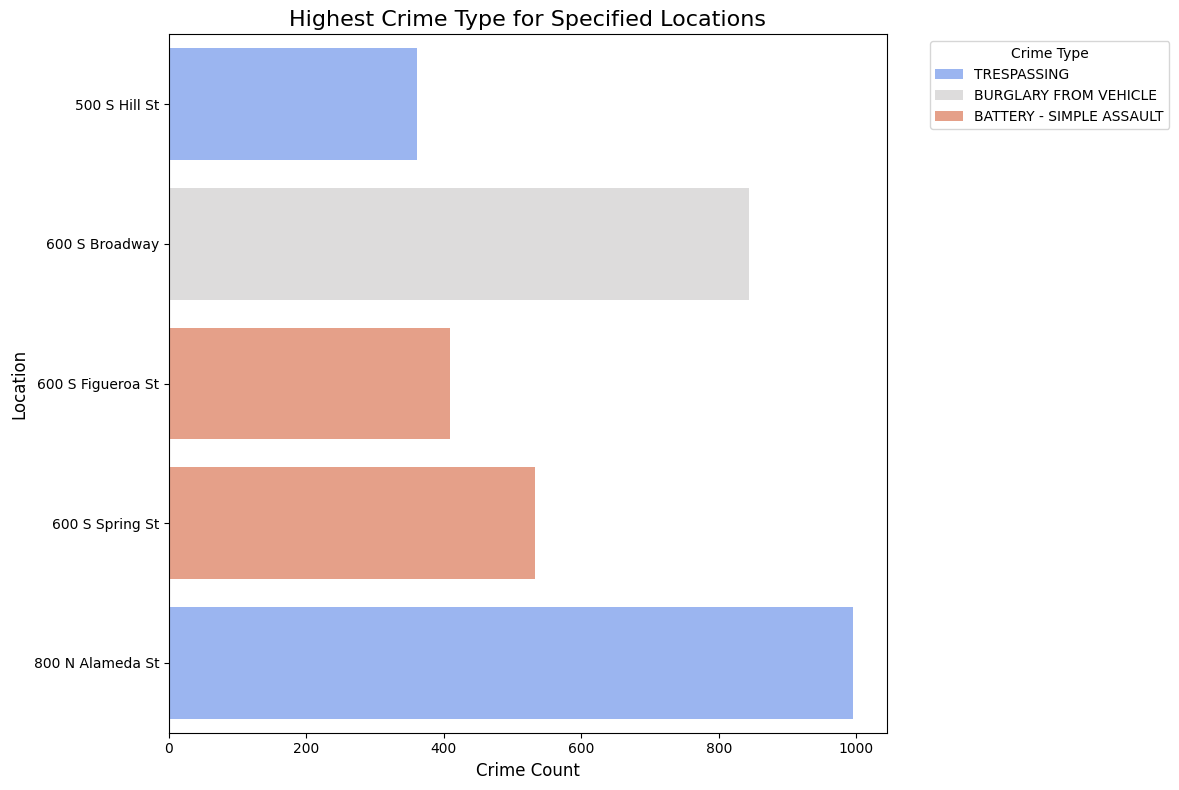

In [59]:
# Filter to find only the highest crime type for each location
highest_crime_per_location_filtered = highest_crime_per_location.loc[
    highest_crime_per_location.groupby('location')['Crime Count'].idxmax()
]

# Plot the data
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Crime Count',
    y='location',
    data=highest_crime_per_location_filtered,
    hue='crm_cd_desc',
    dodge=False,
    palette='coolwarm'
)

# Add titles and labels
plt.title("Highest Crime Type for Specified Locations", fontsize=16)
plt.xlabel("Crime Count", fontsize=12)
plt.ylabel("Location", fontsize=12)

# Add legend for crime types
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


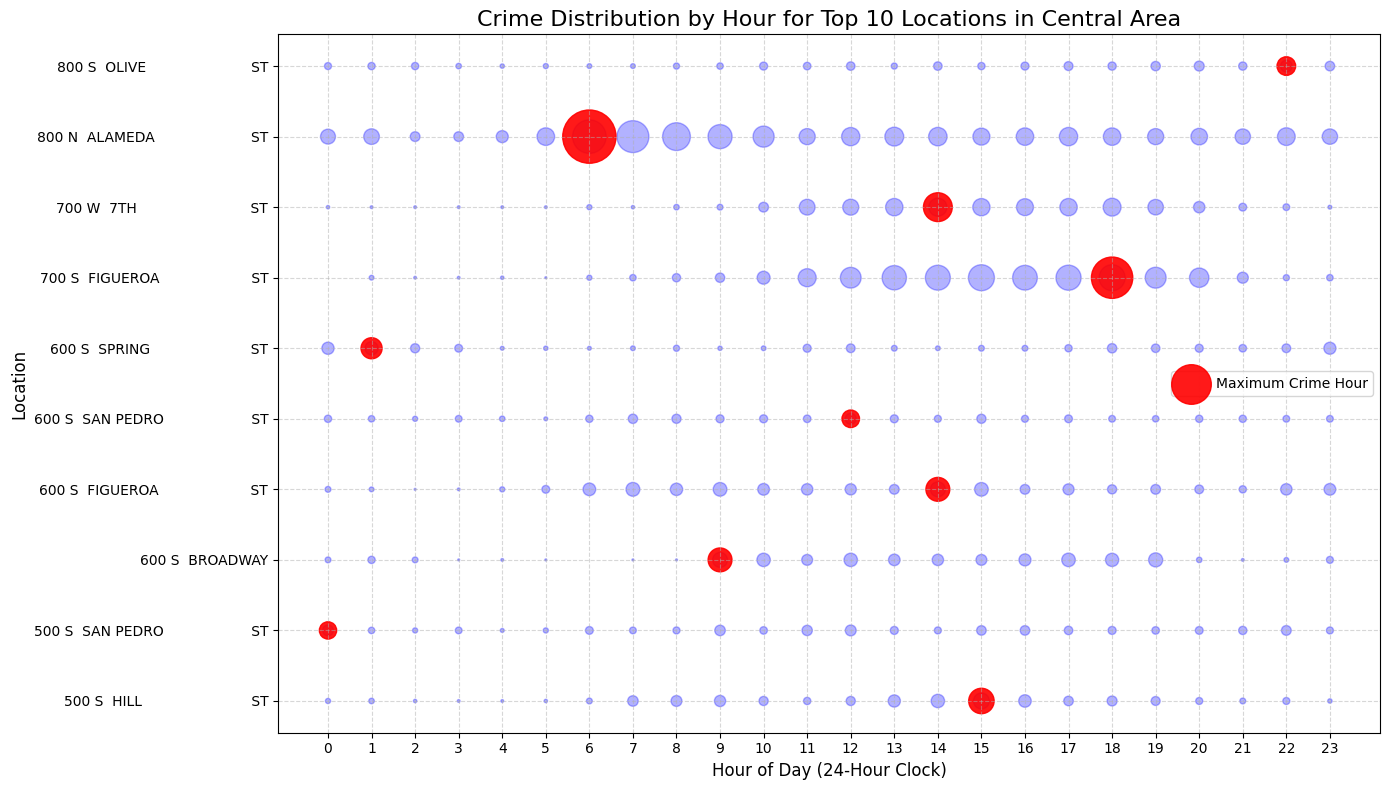

In [52]:
# Assuming `filtered_top_10_data` contains 'location', 'hour', and 'Crime Count'

# Step 1: Aggregate data for plotting all hours
hourly_crime_data = (
    filtered_top_10_data.groupby(['location', 'hour'])
    .size()
    .reset_index(name='Crime Count')
)

# Step 2: Find the hour with maximum crimes for each location
max_hour_per_location = (
    hourly_crime_data.sort_values(by=['location', 'Crime Count'], ascending=[True, False])
    .groupby('location')
    .first()
    .reset_index()
)

# Step 3: Plot the scatter plot
plt.figure(figsize=(14, 8))

# Plot all hours with lighter dots
for location in hourly_crime_data['location'].unique():
    location_data = hourly_crime_data[hourly_crime_data['location'] == location]
    plt.scatter(
        location_data['hour'], 
        [location] * len(location_data), 
        s=location_data['Crime Count'] * 2,  # Scale dot size by crime count
        alpha=0.3, 
        c='blue', 
        label=None  # Do not label these points
    )

# Highlight maximum crime hour with larger red dots
plt.scatter(
    max_hour_per_location['hour'], 
    max_hour_per_location['location'], 
    s=max_hour_per_location['Crime Count'] * 5,  # Larger size for max points
    alpha=0.9, 
    c='red', 
    label='Maximum Crime Hour'
)

plt.title("Crime Distribution by Hour for Top 10 Locations in Central Area", fontsize=16)
plt.xlabel("Hour of Day (24-Hour Clock)", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
# List of specific locations to analyze
specific_locations = [
    "500 S Hill St", "600 S Broadway", "800 N Alameda St", 
    "600 S Figueroa St", "600 S Spring St"
]

# Approximate coordinates for the specified locations
location_coords = {
    "500 S Hill St": (34.0505, -118.2525),
    "600 S Broadway": (34.0472, -118.2568),
    "800 N Alameda St": (34.0564, -118.2362),
    "600 S Figueroa St": (34.0502, -118.2598),
    "600 S Spring St": (34.0469, -118.2512)
}

# Initialize a results list
results = []

for loc, coords in location_coords.items():
    # Filter crime data near the given coordinates (adjusted radius to 0.002 degrees)
    nearby_crimes = df[
        (df['lat'].between(coords[0] - 0.002, coords[0] + 0.002)) &
        (df['lon'].between(coords[1] - 0.002, coords[1] + 0.002))
    ]
    
    if not nearby_crimes.empty:
        # Group by crime type and count occurrences
        crime_type_counts = nearby_crimes.groupby('crm_cd_desc').size().reset_index(name='count')
        highest_crime = crime_type_counts.sort_values('count', ascending=False).iloc[0]
        
        # Find the peak time for the highest crime type
        peak_time = (
            nearby_crimes[nearby_crimes['crm_cd_desc'] == highest_crime['crm_cd_desc']]
            .groupby('time_occ')
            .size()
            .idxmax()
        )
        
        # Append the result for the location
        results.append({
            "Location": loc,
            "Highest Crime Type": highest_crime['crm_cd_desc'],
            "Crime Count": highest_crime['count'],
            "Peak Time Occurred": peak_time
        })
    else:
        results.append({
            "Location": loc,
            "Highest Crime Type": "No Data",
            "Crime Count": 0,
            "Peak Time Occurred": "N/A"
        })

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

# Display the results
print(results_df)


            Location        Highest Crime Type  Crime Count Peak Time Occurred
0      500 S Hill St               TRESPASSING          361              14:00
1     600 S Broadway     BURGLARY FROM VEHICLE          844              20:00
2   800 N Alameda St               TRESPASSING          995              06:30
3  600 S Figueroa St  BATTERY - SIMPLE ASSAULT          409              14:30
4    600 S Spring St  BATTERY - SIMPLE ASSAULT          532              23:00


In [32]:
# Filter data for the selected areas
selected_areas = ['Central', '77th Street', 'Pacific']
filtered_data = df[df['area_name'].isin(selected_areas)]

# Group by area and crime type, count occurrences
crime_counts = (
    filtered_data.groupby(['area_name', 'crm_cd_desc'])
    .size()
    .reset_index(name='crime_count')
)

# Sort the grouped data by area and crime count in descending order
sorted_crime_counts = crime_counts.sort_values(['area_name', 'crime_count'], ascending=[True, False])

# Get the top 3 crime types for each area
top_3_crimes = sorted_crime_counts.groupby('area_name').head(3).reset_index(drop=True)

# Display the results
print("Top 3 crime types in each area:")
print(top_3_crimes)


Top 3 crime types in each area:
     area_name                                        crm_cd_desc  crime_count
0  77th Street     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT         5905
1  77th Street                           BATTERY - SIMPLE ASSAULT         4687
2  77th Street                  INTIMATE PARTNER - SIMPLE ASSAULT         4055
3      Central                              BURGLARY FROM VEHICLE         9339
4      Central                           BATTERY - SIMPLE ASSAULT         6798
5      Central  VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...         4708
6      Pacific                 THEFT PLAIN - PETTY ($950 & UNDER)         4844
7      Pacific                                           BURGLARY         4400
8      Pacific                              BURGLARY FROM VEHICLE         3873


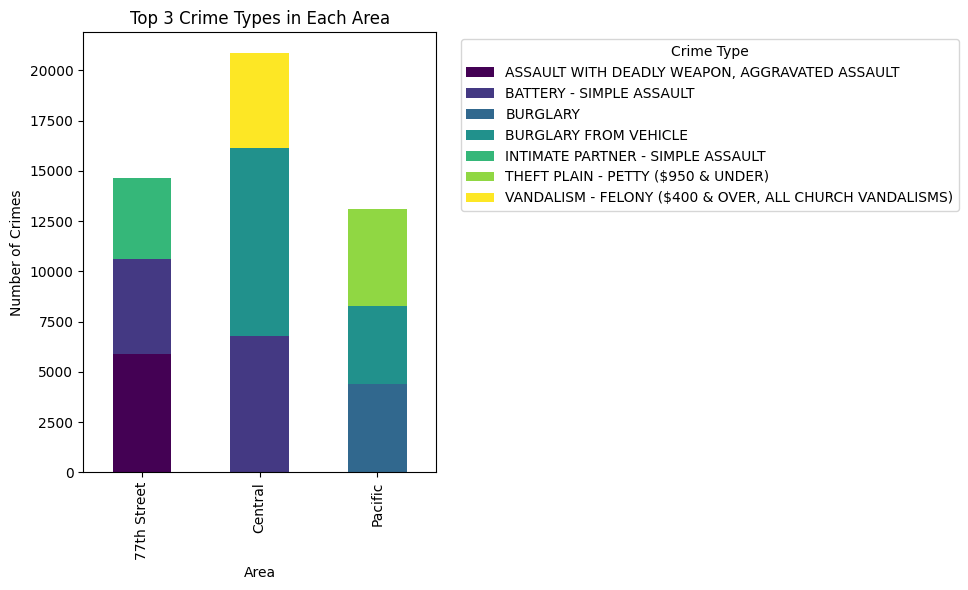

In [33]:
# Pivot data for visualization
stacked_data = top_3_crimes.pivot(index='area_name', columns='crm_cd_desc', values='crime_count').fillna(0)

# Plot a stacked bar chart
stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='viridis'
)

# Customize the chart
plt.title('Top 3 Crime Types in Each Area')
plt.xlabel('Area')
plt.ylabel('Number of Crimes')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


Top 5 weapons used for top 3 crimes in selected areas:
                                       weapon_desc  weapon_count
56  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)         22872
66                     UNKNOWN WEAPON/OTHER WEAPON          6798
24                                        HAND GUN          1510
64                                 UNKNOWN FIREARM           970
31                               MACE/PEPPER SPRAY           741


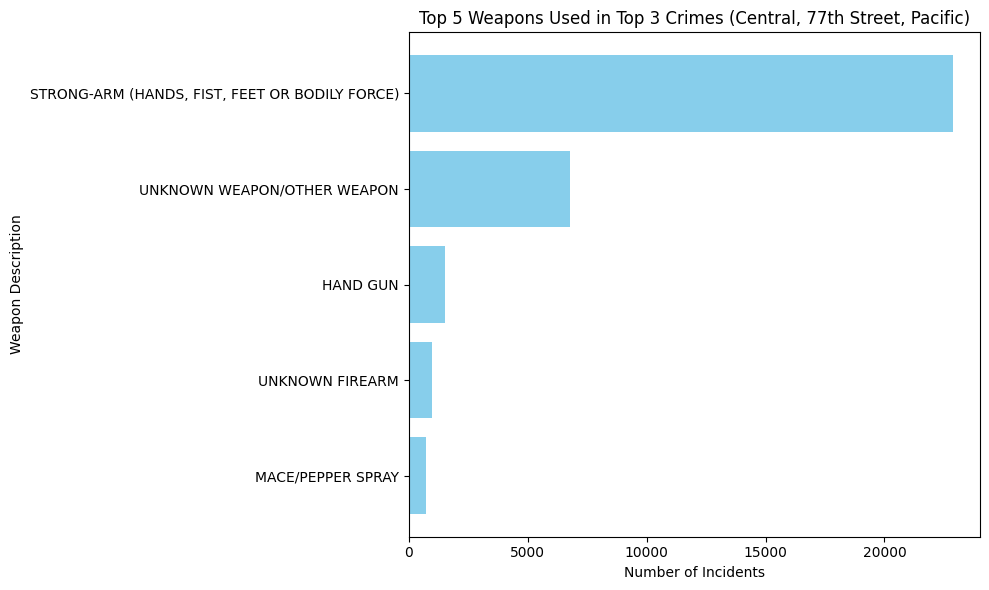

In [34]:
# Filter the dataset for the top 3 crimes in the selected areas
filtered_data = df[
    (df['area_name'].isin(['Central', '77th Street', 'Pacific'])) &
    (df['crm_cd_desc'].isin(top_3_crimes['crm_cd_desc']))
]

# Group by weapon description and count occurrences
weapon_counts = (
    filtered_data.groupby('weapon_desc')
    .size()
    .reset_index(name='weapon_count')
    .sort_values('weapon_count', ascending=False)
)

# Get the top 10 weapons
top_5_weapons = weapon_counts.head(5)

# Display the results
print("Top 5 weapons used for top 3 crimes in selected areas:")
print(top_5_weapons)

# Visualization: Top 10 weapons used
plt.figure(figsize=(10, 6))
plt.barh(
    top_5_weapons['weapon_desc'], 
    top_5_weapons['weapon_count'], 
    color='skyblue'
)
plt.xlabel('Number of Incidents')
plt.ylabel('Weapon Description')
plt.title('Top 5 Weapons Used in Top 3 Crimes (Central, 77th Street, Pacific)')
plt.gca().invert_yaxis()  # Invert y-axis to show the highest count at the top
plt.tight_layout()

# Show the plot
plt.show()


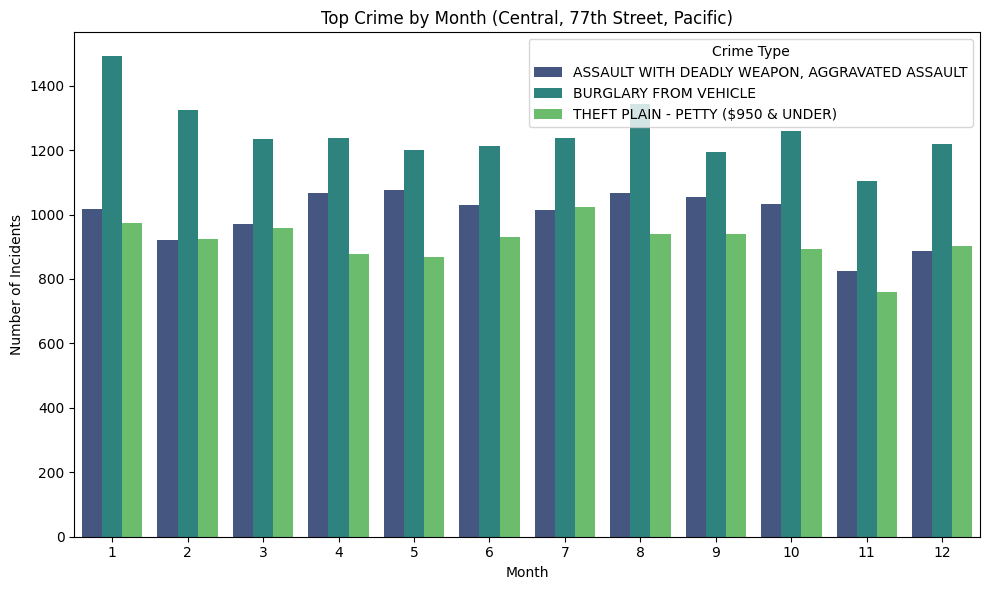

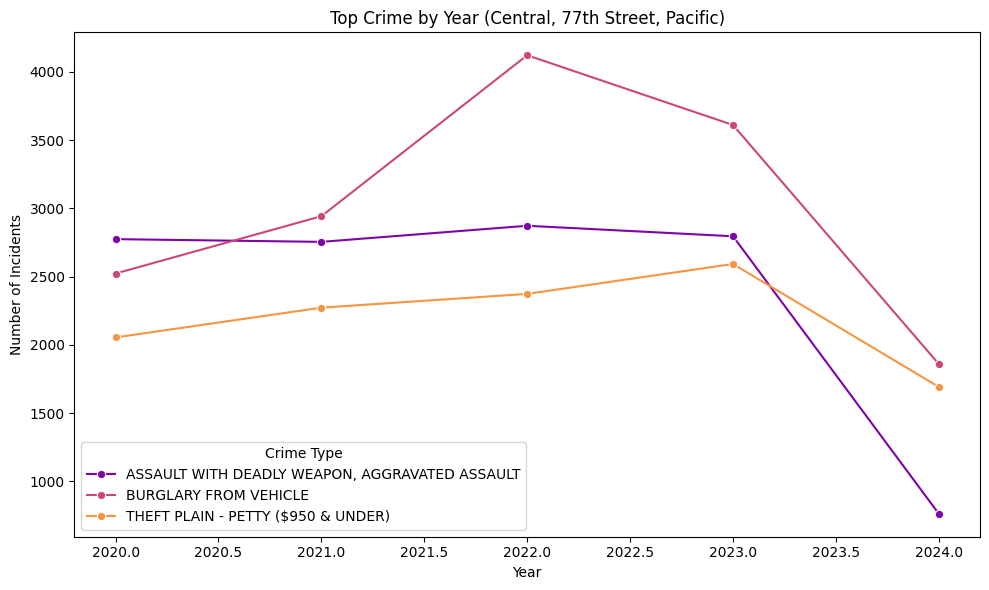

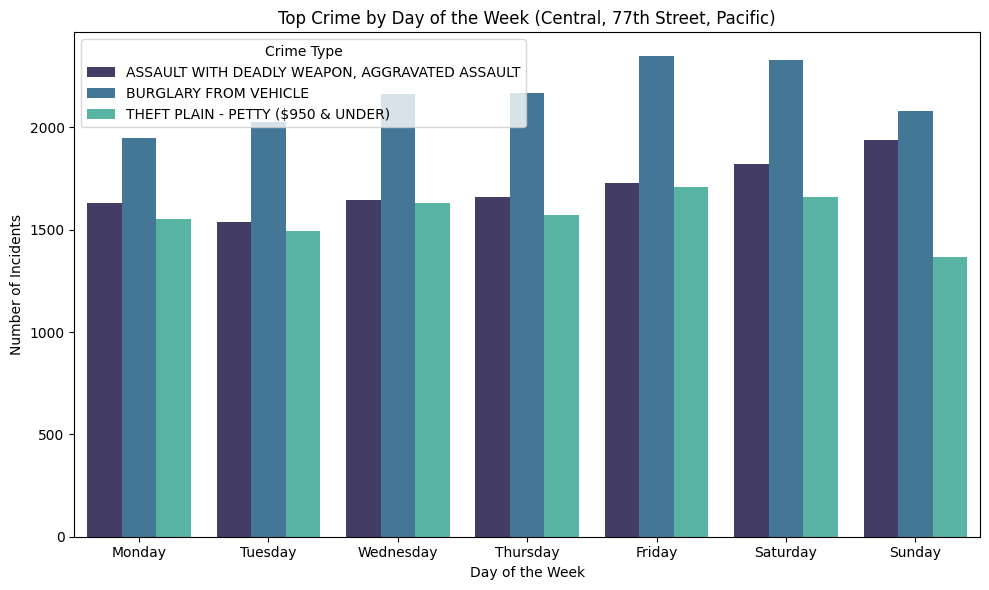

In [35]:
# Identify the top crime in each area
top_crime = (
    df[df['area_name'].isin(['Central', '77th Street', 'Pacific'])]
    .groupby(['area_name', 'crm_cd_desc'])
    .size()
    .reset_index(name='crime_count')
    .sort_values(['area_name', 'crime_count'], ascending=[True, False])
    .groupby('area_name')
    .first()
    .reset_index()
)

# Filter the dataset for the top crime in each area
filtered_data = df[
    (df['area_name'].isin(['Central', '77th Street', 'Pacific'])) &
    (df['crm_cd_desc'].isin(top_crime['crm_cd_desc']))
].copy()

# Convert date columns to datetime if not already done
filtered_data['date_occ'] = pd.to_datetime(filtered_data['date_occ'])

# Extract time attributes
filtered_data['year'] = filtered_data['date_occ'].dt.year
filtered_data['month'] = filtered_data['date_occ'].dt.month
filtered_data['day_of_week'] = filtered_data['date_occ'].dt.day_name()

# Group by month, year, and day of week for analysis
month_counts = filtered_data.groupby(['crm_cd_desc', 'month']).size().reset_index(name='count')
year_counts = filtered_data.groupby(['crm_cd_desc', 'year']).size().reset_index(name='count')
day_counts = filtered_data.groupby(['crm_cd_desc', 'day_of_week']).size().reset_index(name='count')

# Sort days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts['day_of_week'] = pd.Categorical(day_counts['day_of_week'], categories=day_order, ordered=True)

# Visualization: Crimes by Month
plt.figure(figsize=(10, 6))
sns.barplot(data=month_counts, x='month', y='count', hue='crm_cd_desc', palette='viridis')
plt.title('Top Crime by Month (Central, 77th Street, Pacific)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.legend(title='Crime Type')
plt.tight_layout()
plt.show()

# Visualization: Crimes by Year
plt.figure(figsize=(10, 6))
sns.lineplot(data=year_counts, x='year', y='count', hue='crm_cd_desc', marker='o', palette='plasma')
plt.title('Top Crime by Year (Central, 77th Street, Pacific)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.legend(title='Crime Type')
plt.tight_layout()
plt.show()

# Visualization: Crimes by Day of the Week
plt.figure(figsize=(10, 6))
sns.barplot(data=day_counts, x='day_of_week', y='count', hue='crm_cd_desc', palette='mako')
plt.title('Top Crime by Day of the Week (Central, 77th Street, Pacific)')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Incidents')
plt.legend(title='Crime Type')
plt.tight_layout()
plt.show()


In [41]:
!pip install pandas numpy matplotlib pyfiglet plotly dash holoviews geoviews bokeh cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 67.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 45.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 MB 36.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.8/116.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 11.3 MB/s eta 0:00:00


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyfiglet
import plotly.graph_objects as go
import dash

from dash import dcc, html
from dash.dependencies import Input, Output
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go

In [53]:
from dash import Input, Output, dcc, html
import plotly.express as px

area_gender_app = dash.Dash(__name__)

class CrimeDashBoardBasedOnAreaGender:
    def __init__(self, app, df):
        """
        Initialize the CrimeDashBoardBasedOnGender class with Dash app instance and dataset.
        """
        self.app = app
        self.df = df

    def victims_gender_layout(self):
        """
        Define the Dash layout for displaying total crimes and toggling between male and female victims.
        """
        self.app.layout = html.Div([
            # Display Total Crimes
            html.H3(id="total-crimes", style={'textAlign': 'center', 'marginBottom': '20px'}),

            # Buttons for Male and Female Victims
            html.Div([
                html.Button("Male Victims", id="btn-male", n_clicks=0, style={'marginRight': '10px'}),
                html.Button("Female Victims", id="btn-female", n_clicks=0),
            ], style={'textAlign': 'center', 'marginBottom': '20px'}),

            # Crime Chart
            dcc.Graph(id="crime-chart", figure=px.bar())
        ])

    def add_callbacks(self):
        """
        Add Dash callbacks for interactive functionality to toggle data by victim gender.
        """
        @self.app.callback(
            [Output("total-crimes", "children"),
             Output("crime-chart", "figure")],
            [Input("btn-male", "n_clicks"),
             Input("btn-female", "n_clicks")]
        )
        def update_dashboard(n_clicks_male, n_clicks_female):
            """
            Update the dashboard based on button clicks.
            """
            # Determine which button was clicked
            if n_clicks_male > n_clicks_female:
                filtered_df = self.df[self.df['vict_sex'] == "M"]
                title = "Crimes with Male Victims"
            elif n_clicks_female > n_clicks_male:
                filtered_df = self.df[self.df['vict_sex'] == "F"]
                title = "Crimes with Female Victims"
            else:
                # Default to all data if no button or equal clicks
                filtered_df = self.df
                title = "Total Crimes"

            # Total Crimes Count
            total_crimes = len(filtered_df)

            # Filter and group data for the chart
            area_filter = ['Central', '77th Street', 'Pacific']
            grouped_data = (
                filtered_df[filtered_df['area_name'].isin(area_filter)]
                .groupby(['area_name'])
                .size()
                .reset_index(name='count')
                .sort_values(by='count', ascending=False)
            )

            # Create the bar chart
            fig = px.bar(
                grouped_data,
                x='count',
                y='area_name',
                orientation='h',
                color='area_name',
                title=title,
                labels={'count': 'Count', 'area_name': 'Area Name'}
            )
            fig.update_layout(showlegend=False, template="plotly_white")

            # Return updated total crimes text and chart figure
            return f"Total Crimes: {total_crimes}", fig


# Instantiate the dashboard
# Replace `df` with your actual DataFrame
dashboard = CrimeDashBoardBasedOnAreaGender(area_gender_app, df)
dashboard.victims_gender_layout()
dashboard.add_callbacks()
area_gender_app.run_server(debug=True,port=8051)

### Step 4: Meeting Schedule 

We are all busy. You and your team should be working towards this project on a weekly basis. Share your proposed schedule below.

`--== Double-click and describe your project schedule below  ==--`

1. Weekly Team Meetings (Every Sunday at 4:00 PM)

Goal: Review progress, assign tasks for the upcoming week, discuss challenges, and ensure alignment.
Duration: 1 hour
Agenda:
Status updates from each team member
Roadblocks and support needed
Review of previous week’s tasks
Set tasks for the upcoming week

2. Project Progress Report (Due 11/17)

Meeting Date: 11/14 (Wednesday)
Goal: Discuss the draft of the progress report. Ensure all members provide updates on their tasks.
Agenda:
Complete draft of the progress report
Identify sections for further research or analysis
Ensure the report aligns with the overall project goals

3. Poster Presentation (Due 12/6)

Meeting Date: 12/2 (Sunday)
Goal: Finalize poster design, ensuring clarity in data visualization and key findings.
Agenda:
Review and finalize poster content
Check formatting and visualizations
Plan presentation delivery (who will speak on which parts)

4. Final Project (Due 12/15)

Meeting Date: 12/9 (Sunday)
Goal: Ensure all aspects of the final project are ready for submission. Review interactive dashboard, analysis results, and final report.
Agenda:
Final checks on interactive dashboard and visualizations
Review final report draft
Plan any last-minute adjustments
Ensure all documentation is complete

Additional Check-ins (if needed):

Ad-Hoc meetings may be scheduled to address issues that arise during the development or analysis phases. These will be short, focused meetings to resolve specific challenges.